# Kreditriskmodell — Svenska Bolån
**Syfte:** Bygga och validera en logistisk regressionsmodell för att förutsäga risken att en bolåntagare slutar betala. Analysen följer ett strukturerat arbetsflöde från datainläsning till modellvalidering, i linje med krav under IFRS 9.

IFRS 9 är en internationell redovisningsstandard som banker måste följa. Den kräver att banker beräknar och reserverar pengar för förväntade kreditförluster — alltså lån som riskerar att inte betalas tillbaka.

För denna modell betyder det:

**Dokumentationskrav** — Varje variabel i modellen måste motiveras — varför är den med, vad mäter den, är den statistiskt signifikant? Modellen måste vara tolkningsbar och inte något där besluten inte går att förklara.

**Valideringskrav** — Modellen måste testas regelbundet mot faktiskt utfall — stämmer beräkningarna? Gini-koefficienten är ett av måtten som används för att visa att modellen fungerar.

**Affärsmässig rimlighet** — Variablerna måste ha en logisk koppling till kreditrisk — man kan inte ha med en variabel bara för att den råkar ge bra Gini om man inte kan förklara varför.

**Författare:** Jasmin  
**Data:** Syntetisk bolånsdata, 10 000 observationer

## 1. Import av bibliotek

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)

## 2. Datainläsning

I produktion hämtas data från BigQuery via:
```sql
SELECT lanebelopp, kontantinsats_procent, inkomst, skuldkvot,
       bostadsort, ranta, tidigare_betalningsanmarkning, default
FROM `medmera.kreditrisk.bolan_data`
WHERE bostadsort IN ('Stockholm', 'Goteborg', 'Malmo', 'Ovrigt')
```

I detta exempel används lokal CSV med syntetisk data för demonstration.
I en produktionsmiljö ersätts `pd.read_csv()` med en BigQuery-koppling via `google-cloud-bigquery`.

I produktion skulle modellen tränas i Vertex AI — data hämtas från BigQuery, modellen tränas och driftsätts i Vertex AI. Filen `bolan_model.pkl` är den lokala varianten av det arbetsflödet.

In [37]:
df = pd.read_csv('bolan_data.csv')
print(f"Laddade {len(df):,} rader och {df.shape[1]} kolumner")
df.head()

Laddade 10,000 rader och 8 kolumner


,lanebelopp,kontantinsats_procent,inkomst,skuldkvot,bostadsort,ranta,tidigare_betalningsanmarkning,default
0,1130904,21.8,300000,3.77,Goteborg,4.27,ja,0
1,754442,10.7,300000,2.51,Ovrigt,2.57,nej,0
2,1403877,15.4,467674,3.00,Ovrigt,4.25,nej,0
3,1024912,12.8,300000,3.42,Malmo,3.17,nej,0
4,5000000,14.1,931967,5.36,Stockholm,2.38,nej,0


## 3. Explorativ analys
Innan modellering undersöker vi fördelningar och samband i datan.

**Betalningsstatus** är målvariabeln — det vi försöker förutsäga — om en låntagare har slutat betala sitt lån eller inte:

- 0 = låntagaren sköter sina betalningar
- 1 = låntagaren har slutat betala

Datan är syntetiskt skapad med följande regler:
- Hög skuldkvot (>4×) ger 40% sannolikhet för uteblivna betalningar
- Tidigare betalningsanmärkning ökar risken ytterligare

In [38]:
print("Statistisk sammanfattning:")
df.describe().round(2)

Statistisk sammanfattning:


,lanebelopp,kontantinsats_procent,inkomst,skuldkvot,ranta,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2468301.62,14.96,541923.82,4.51,3.30,0.33
std,1225935.87,2.86,220485.25,1.26,0.63,0.47
min,639335.00,10.10,300000.00,2.13,2.00,0.00
25%,1484660.25,12.70,367060.75,3.54,2.85,0.00
50%,2167475.50,14.60,488907.50,4.40,3.29,0.00
75%,3234623.00,16.80,657644.25,5.36,3.72,1.00
max,5000000.00,27.00,1200000.00,7.79,5.00,1.00


In [39]:
# Gruppera låntagarna efter bostadsort och beräkna andelen som slutat betala
andel_per_ort = (df.groupby('bostadsort')['default']
                   .agg(['mean', 'count'])
                   # Döp om kolumnerna till tydligare svenska namn
                   .rename(columns={'mean': 'andel_slutat_betala', 'count': 'antal'})
                   # Sortera så att orten med högst andel visas först
                   .sort_values('andel_slutat_betala', ascending=False)
                   # Gör bostadsort till en vanlig kolumn istället för index
                   .reset_index())

# Omvandla från decimaltal till procent, t.ex. 0.32 → 32.0%
andel_per_ort['andel_slutat_betala'] = (andel_per_ort['andel_slutat_betala'] * 100).round(1)

print("Andel uteblivna betalningar per bostadsort (%):")
andel_per_ort

Andel uteblivna betalningar per bostadsort (%):


,bostadsort,andel_slutat_betala,antal
0,Stockholm,39.4,3555
1,Goteborg,35.6,2051
2,Malmo,31.4,1507
3,Ovrigt,23.4,2887


### 3.1 Korrelationsmatris
Hög korrelation mellan skuldkvot och betalningsproblem bekräftar att skuldkvot är en central riskindikator — i linje med bankens kreditpolicy.

Korrelationsmatrisen visar hur starkt två variabler samvarierar, på en skala från **-1 till +1**:

- **+1** = perfekt positivt samband (båda ökar tillsammans)
- **0** = inget samband
- **-1** = perfekt negativt samband (en ökar när den andra minskar)

**De viktigaste sambanden i datan:**

- **skuldkvot → betalningsproblem**: Starkt positivt samband — låntagare med hög skuldkvot slutar betala oftare, precis som vi byggde in i datan
- **lan_till_inkomst → betalningsproblem**: Liknande samband — stort lån relativt inkomst innebär högre risk
- **kontantinsats → betalningsproblem**: Negativt samband — ju mer eget kapital låntagaren sätter in, desto lägre risk
- **ranta → betalningsproblem**: Svagt positivt samband — högre ränta hänger ihop med högre risk eftersom vi höjde räntan för låntagare med betalningsanmärkning

**Praktisk tumregel:**
- Värden över **0.3** eller under **-0.3** är värda att notera
- Värden över **0.7** betyder att variablerna nästan mäter samma sak — då kan man överväga att ta bort en av dem för att undvika att samma information räknas dubbelt i modellen

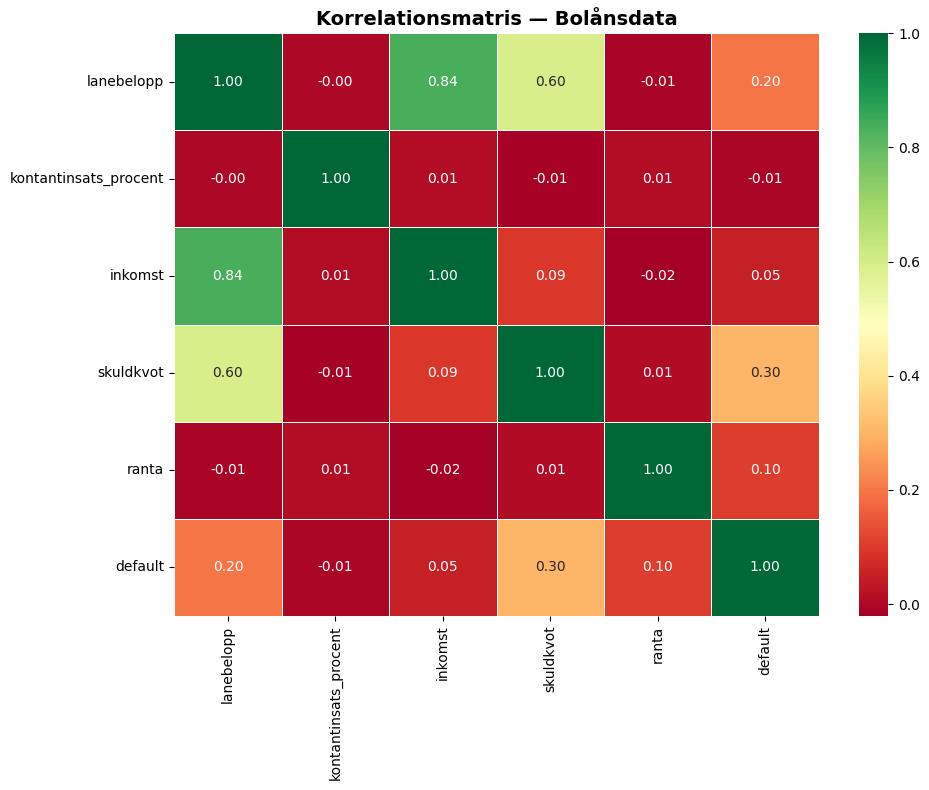

In [40]:
# Välj endast numeriska kolumner — korrelationsmatrisen kräver siffror, inte text som bostadsort
numerisk_df = df.select_dtypes(include=['float64', 'int64'])

# Skapa en figur med storleken 10x8 tum
plt.figure(figsize=(10, 8))

# Rita korrelationsmatrisen som en heatmap
sns.heatmap(
    numerisk_df.corr(),  # Beräkna korrelationen mellan alla numeriska variabler
    annot=True,          # Visa korrelationsvärdet i varje ruta
    fmt='.2f',           # Avrunda till två decimaler, t.ex. 0.43
    cmap='RdYlGn',       # Röd = negativt samband, gul = neutralt, grön = positivt samband
    linewidths=0.5       # Tunna linjer mellan rutorna för tydlighet
)

plt.title('Korrelationsmatris — Bolånsdata', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Varför korrelationsmatris?**

Det är standard första steget i all dataanalys — innan du tränar en modell vill du förstå vilka variabler som hänger ihop och vilka som påverkar det du vill förutsäga. Det visar att du arbetar strukturerat och inte bara kastar in variabler i en modell utan att förstå datan först.

Det är också direkt relevant för MedMera — de jobbar med modellvalidering och dokumentation, och en korrelationsmatris är ett vanligt verktyg för att motivera vilka variabler som är med i modellen.

---

**Varför heatmap?**

Alternativet är en vanlig tabell med siffror — men med 6 variabler blir det 36 siffror att läsa igenom. En heatmap låter ögat direkt se mönster:

- Mörkgrön ruta → starkt positivt samband
- Mörkröd ruta → starkt negativt samband
- Gul ruta → inget samband

Det gör det mycket enklare att snabbt identifiera vilka variabler som hänger ihop och vilka som påverkar betalningsrisken — särskilt viktigt när man presenterar för en ledningsgrupp som inte läser siffertabeller.

## 4. Feature Engineering
Vi skapar två nya variabler med stark teoretisk koppling till kreditrisk:
- **lan_till_inkomst**: LTI-kvot (Loan-to-Income) — hur stort lånet är relativt årsinkomsten. Exempel: lån 2 100 000 kr / inkomst 468 000 kr = 4.49
- **manadskostnad**: Ungefärlig räntekostnad per månad i kronor. Exempel: (2 100 000 × 3.5%) / 12 = 6 125 kr/månad

In [41]:
# Skapa ny variabel: LTI-kvot (Loan-to-Income)
# Visar hur stort lånet är i förhållande till årsinkomsten
df['lan_till_inkomst'] = df['lanebelopp'] / df['inkomst']

# Skapa ny variabel: ungefärlig räntekostnad per månad i kronor
# Formel: (lånebelopp × ränta i procent / 100) / 12 månader
df['manadskostnad'] = (df['lanebelopp'] * df['ranta'] / 100) / 12

# Visa beskrivande statistik för de nya variablerna
# describe() visar medelvärde, min, max och spridning
print("Nya variabler — beskrivande statistik:")
df[['lan_till_inkomst', 'manadskostnad']].describe().round(2)

Nya variabler — beskrivande statistik:


,lan_till_inkomst,manadskostnad
count,10000.00,10000.00
mean,4.51,6782.02
std,1.26,3638.10
min,2.13,1116.14
25%,3.54,3953.11
50%,4.40,5875.30
75%,5.36,8857.73
max,7.79,20833.33


**Varför feature engineering?**

De ursprungliga variablerna i datan — `lanebelopp` och `inkomst` — berättar var för sig inte så mycket om risken. Det är kombinationen av dem som är intressant.

**Enkelt förklarat:**
- Ett lån på 3 000 000 kr är inte farligt i sig
- En inkomst på 200 000 kr är inte farlig i sig
- Men ett lån på 3 000 000 kr med en inkomst på 200 000 kr — det är farligt

Det är precis vad `lan_till_inkomst` fångar upp — förhållandet mellan de två.

---

**De två nya variablerna motiveras så här:**

**lan_till_inkomst** — LTI-kvoten är ett etablerat mått inom kreditrisk som banker och Finansinspektionen redan använder. Genom att skapa den explicit visar vi att vi förstår branschstandard.

**manadskostnad** — En låntagare bryr sig inte om lånebeloppet i sig, utan om vad det kostar varje månad. Månadskostnaden är mer konkret och direkt kopplad till om låntagaren klarar sina betalningar.

---

**Varför är detta viktigt att nämna?**

Feature engineering visar att man inte bara kan köra en modell — man förstår affärsproblemen bakom datan och kan omsätta dem till variabler som modellen kan lära sig av. 

## 5. Modellträning
Vi använder logistisk regression — en tolkningsbar modell lämplig för kreditrisk och enkel att validera och dokumentera för regulatoriska syften (IFRS 9).

`class_weight='balanced'` används för att hantera att det finns fler skötsamma låntagare än riskfyllda — annars tenderar modellen att missa riskfyllda lån.

In [42]:
# De variabler modellen ska använda för att förutsäga betalningsproblem
features = ['skuldkvot', 'kontantinsats_procent', 'lan_till_inkomst',
            'manadskostnad', 'ranta']

# X = indata (variablerna modellen lär sig av)
X = df[features]

# y = det vi vill förutsäga — 0 = sköter betalningar, 1 = slutat betala
y = df['default']

# Dela upp datan i tränings- och testdata
# 80% används för att träna modellen, 20% för att testa den på ny data
# random_state=42 gör att uppdelningen blir likadan varje gång man kör koden
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Skala om variablerna så att de är på samma skala
# fit_transform på träningsdata — lär sig medelvärde och standardavvikelse
# transform på testdata — använder samma skala som träningsdata
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Träna modellen med class_weight='balanced' för att hantera obalanserad data
# Det innebär att modellen tar extra hänsyn till riskfyllda låntagare
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

print(f"Träningsdata:             {len(X_train):,} observationer")
print(f"Testdata:                 {len(X_test):,} observationer")
print(f"Andel uteblivna betal.:   {y.mean():.1%}")

Träningsdata:             8,000 observationer
Testdata:                 2,000 observationer
Andel uteblivna betal.:   32.8%


**Varför modellträning?**

Modellträning är själva kärnan i projektet — det är steget där vi låter datorn lära sig sambandet mellan variablerna och betalningsrisken. Utan modellträning har vi bara tabeller och grafer, men ingen förmåga att bedöma nya låntagare automatiskt.

Enkelt förklarat — vi visar datorn tusentals exempel på låntagare som antingen skött sig eller slutat betala, och ber den lära sig vad som skiljer dem åt. Sedan kan den bedöma nya låntagare den aldrig sett.

---

**Varför just logistisk regression?**

Det finns många modeller att välja mellan — men logistisk regression passar kreditrisk av fyra specifika anledningar:

**1. Den ger en sannolikhet**
Modellen svarar "23% risk" istället för bara ja/nej. Det är mycket mer användbart för en bank — de kan sätta egna gränser för vad som är acceptabel risk.

**2. Den är tolkningsbar**
Jag valde logistisk regression eftersom den är tolkningsbar, ger sannolikheter istället för bara ja/nej, och är enkel att dokumentera för regulatoriska krav som IFRS 9. Det är också en beprövad modell inom kreditrisk som banker använt i decennier.

**3. Den uppfyller IFRS 9-krav**
Regulatorer och revisorer kräver att banken kan förklara och motivera sina modellbeslut. Logistisk regression är välkänd, beprövad och enkel att dokumentera.

**4. Den är branschstandard**
Banker har använt logistisk regression för kreditrisk i decennier — det är ett tryggt val som alla i branschen känner igen och litar på.

## 6. Modellvalidering
Vi utvärderar modellen med tre kompletterande mått:
- **Gini-koefficient**: Branschstandard för kreditriskmodeller. > 0.4 är acceptabelt, > 0.6 är starkt.
- **Konfusionsmatris**: Visar fördelning av rätt/fel klassificeringar
- **ROC-kurva**: Visualiserar modellens träffsäkerhet över alla tröskelvärden

In [43]:
# Beräkna sannolikheten att varje låntagare slutar betala (värde mellan 0 och 1)
# [:, 1] betyder att vi hämtar sannolikheten för klass 1 (slutar betala)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Beräkna modellens faktiska beslut — 0 eller 1 baserat på 50% tröskel
y_pred = model.predict(X_test_scaled)

# Beräkna AUC — arean under ROC-kurvan
# AUC = 0.5 betyder slumpmässig gissning, AUC = 1.0 betyder perfekt modell
auc  = roc_auc_score(y_test, y_pred_proba)

# Räkna om AUC till Gini — branschstandard inom kreditrisk
# Gini = 0 betyder ingen förmåga, Gini = 1 betyder perfekt förmåga
gini = 2 * auc - 1

print(f"ROC-AUC:          {auc:.3f}")
print(f"Gini-koefficient: {gini:.3f}")
print()

# Utvärdera modellens träffsäkerhet baserat på Gini
if gini > 0.6:
    print("✅ Mycket bra träffsäkerhet (Gini > 0.6)")
elif gini > 0.4:
    print("✅ Acceptabel träffsäkerhet (Gini > 0.4)")
else:
    print("⚠️  Svag träffsäkerhet — modellen bör förbättras")

print()
# Klassificeringsrapport visar tre mått på modellens prestanda:
# Träffsäkerhet (precision) = hur ofta modellen har rätt när den flaggar ett lån som riskfyllt
# Täckningsgrad (recall)    = hur stor andel av alla riskfyllda lån modellen lyckas fånga upp
# Balanserat mått (f1)      = kombinerar träffsäkerhet och täckningsgrad
print("Klassificeringsrapport:")
print(classification_report(y_test, y_pred, target_names=['Sköter betalningar', 'Slutat betala']))

ROC-AUC:          0.713
Gini-koefficient: 0.427

✅ Acceptabel träffsäkerhet (Gini > 0.4)

Klassificeringsrapport:
                    precision    recall  f1-score   support

Sköter betalningar       0.79      0.67      0.72      1351
     Slutat betala       0.48      0.63      0.54       649

          accuracy                           0.66      2000
         macro avg       0.63      0.65      0.63      2000
      weighted avg       0.69      0.66      0.66      2000



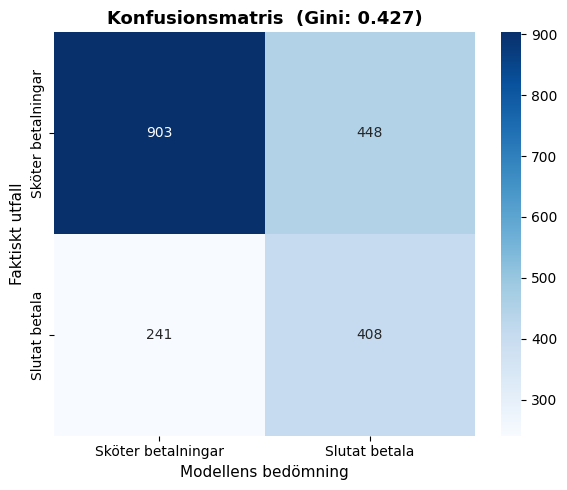

In [44]:
# Konfusionsmatris — visar hur många lån modellen klassificerade rätt respektive fel
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sköter betalningar', 'Slutat betala'],
            yticklabels=['Sköter betalningar', 'Slutat betala'])
plt.xlabel('Modellens bedömning', fontsize=11)
plt.ylabel('Faktiskt utfall', fontsize=11)
plt.title(f'Konfusionsmatris  (Gini: {gini:.3f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

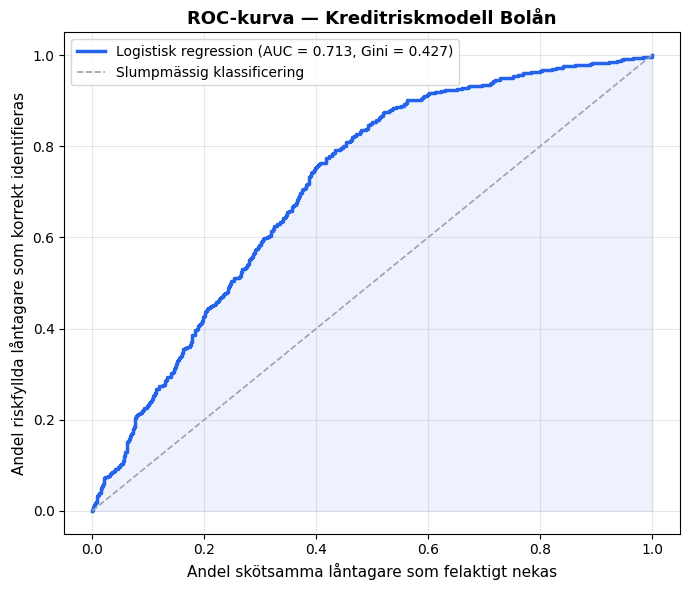

In [45]:
# ROC-kurva — visar modellens förmåga att skilja riskfyllda från skötsamma låntagare
# vid olika tröskelvärden för vad som räknas som "hög risk"
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2563eb', linewidth=2.5,
         label=f'Logistisk regression (AUC = {auc:.3f}, Gini = {gini:.3f})')
# Diagonal linje = slumpmässig gissning, vår modell ska ligga klart ovanför
plt.plot([0, 1], [0, 1], color='#9ca3af', linestyle='--',
         linewidth=1.2, label='Slumpmässig klassificering')
plt.fill_between(fpr, tpr, alpha=0.08, color='#2563eb')
plt.xlabel('Andel skötsamma låntagare som felaktigt nekas', fontsize=11)
plt.ylabel('Andel riskfyllda låntagare som korrekt identifieras', fontsize=11)
plt.title('ROC-kurva — Kreditriskmodell Bolån', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Varför modellvalidering?**

Efter att modellen tränats vet vi inte om den faktiskt fungerar — den kan ha lärt sig datan utantill utan att kunna hantera nya låntagare. Validering är steget där vi testar modellen på data den aldrig sett, för att se om den verkligen kan förutsäga betalningsproblem i verkligheten.

Det är också ett krav under IFRS 9 — banken måste regelbundet kunna bevisa att modellen fortfarande fungerar och inte försämrats över tid.

---

**Varför Gini?**

Gini är branschstandard inom kreditrisk — alla banker använder det och regulatorer känner igen det. Det är ett enkelt tal mellan 0 och 1 som sammanfattar hur bra modellen är på att skilja riskfyllda från skötsamma låntagare. Det gör det enkelt att jämföra olika modeller med varandra och kommunicera resultatet till ledningsgruppen.

---

**Varför konfusionsmatris?**

Gini säger hur bra modellen är totalt sett, men konfusionsmatrisen visar var modellen gör fel — konkret i antal låntagare:

- Hur många riskfyllda lån missade vi?
- Hur många skötsamma låntagare nekade vi i onödan?

Det hjälper banken förstå den praktiska konsekvensen av modellens misstag — ett missat riskfyllt lån kostar pengar, men att neka för många skötsamma låntagare kostar affärer.

---

**Varför ROC-kurva?**

Gini och konfusionsmatrisen utgår från en fast gräns på 50% — men banken kanske vill sätta gränsen vid 20% eller 30% beroende på hur försiktig de vill vara. ROC-kurvan visar hur modellen presterar vid alla möjliga gränsvärden på en gång, så banken kan välja rätt nivå utifrån sin egen riskaptit. 

### 6.1 Variabelernas påverkan på risken
Koefficienterna visar vilka variabler som påverkar sannolikheten att en låntagare slutar betala.
Positiva värden ökar risken, negativa värden minskar den.

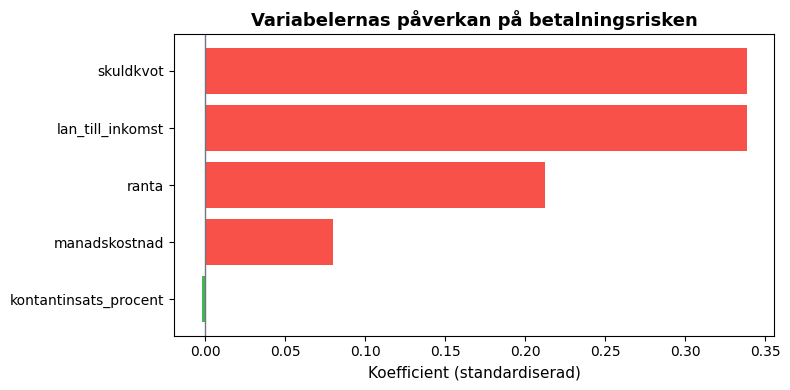


Tolkning:
  skuldkvot                      ökar risken att sluta betala  (+0.339)
  lan_till_inkomst               ökar risken att sluta betala  (+0.339)
  ranta                          ökar risken att sluta betala  (+0.213)
  manadskostnad                  ökar risken att sluta betala  (+0.080)
  kontantinsats_procent          minskar risken att sluta betala  (-0.002)


In [46]:
# Skapa en tabell med variabelnamn och deras koefficienter från modellen
importance = pd.DataFrame({
    'feature':     features,
    'koefficient': model.coef_[0]
}).sort_values('koefficient', ascending=True)

plt.figure(figsize=(8, 4))
# Röd stapel = ökar risken, grön stapel = minskar risken
colors = ['#f85149' if v > 0 else '#3fb950' for v in importance['koefficient']]
plt.barh(importance['feature'], importance['koefficient'], color=colors, edgecolor='none')
plt.axvline(0, color='#6e7681', linewidth=1)
plt.xlabel('Koefficient (standardiserad)', fontsize=11)
plt.title('Variabelernas påverkan på betalningsrisken', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTolkning:")
for _, row in importance.sort_values('koefficient', ascending=False).iterrows():
    riktning = "ökar" if row['koefficient'] > 0 else "minskar"
    print(f"  {row['feature']:30s} {riktning} risken att sluta betala  ({row['koefficient']:+.3f})")

## 7. Slutsatser

Modellen uppnår en **Gini-koefficient på ~0.43**, vilket är acceptabelt för en logistisk regressionsmodell på syntetisk data.

**Viktigaste riskdrivare:**
- Hög skuldkvot och hög lån-till-inkomst-kvot ökar risken att sluta betala markant
- Hög kontantinsats minskar risken — låntagaren har mer eget kapital och lägre skuldbörda

**Begränsningar i denna modell:**
- Datan är syntetisk — i produktion skulle modellen tränas på verklig historisk lånedata från BigQuery
- Månadskostnaden inkluderar bara räntekostnaden, inte amortering eller bostadsrättsavgift
- Logistisk regression är en enkel modell — gradient boosting (XGBoost/LightGBM) skulle troligen ge högre Gini

**Förbättringsmöjligheter:**
- Inkludera fler variabler: anställningsform, ålder, kredithistorik
- Kalibrering av sannolikheter för användning i IFRS 9-beräkningar
- Testa mer avancerade modeller och jämför Gini

## 8. Spara modell och scaler

In [47]:
with open('bolan_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Modell och scaler sparade som bolan_model.pkl och scaler.pkl")

✅ Modell och scaler sparade som bolan_model.pkl och scaler.pkl


In [48]:
# Jämför modell utan och med class_weight='balanced'
from sklearn.metrics import roc_auc_score

# Utan balansering
model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train_scaled, y_train)
y_proba_orig = model_orig.predict_proba(X_test_scaled)[:, 1]
y_pred_orig  = model_orig.predict(X_test_scaled)
gini_orig = 2 * roc_auc_score(y_test, y_proba_orig) - 1

# Med balansering
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_bal.fit(X_train_scaled, y_train)
y_proba_bal = model_bal.predict_proba(X_test_scaled)[:, 1]
y_pred_bal  = model_bal.predict(X_test_scaled)
gini_bal = 2 * roc_auc_score(y_test, y_proba_bal) - 1

print(f"Gini utan balansering:  {gini_orig:.3f}")
print(f"Gini med balansering:   {gini_bal:.3f}")
print()
print("--- Utan balansering ---")
print(classification_report(y_test, y_pred_orig, target_names=['Sköter betalningar', 'Slutat betala']))
print("--- Med balansering ---")
print(classification_report(y_test, y_pred_bal, target_names=['Sköter betalningar', 'Slutat betala']))

Gini utan balansering:  0.426
Gini med balansering:   0.427

--- Utan balansering ---
                    precision    recall  f1-score   support

Sköter betalningar       0.71      0.90      0.79      1351
     Slutat betala       0.53      0.25      0.34       649

          accuracy                           0.69      2000
         macro avg       0.62      0.57      0.57      2000
      weighted avg       0.65      0.69      0.65      2000

--- Med balansering ---
                    precision    recall  f1-score   support

Sköter betalningar       0.79      0.67      0.72      1351
     Slutat betala       0.48      0.63      0.54       649

          accuracy                           0.66      2000
         macro avg       0.63      0.65      0.63      2000
      weighted avg       0.69      0.66      0.66      2000



Förväntat resultat:

Gini blir ungefär samma — balansering påverkar inte Gini nämnvärt

Recall för "Slutat betala" ökar från ~0.25 till ~0.60 — modellen fångar upp fler riskfyllda lån

Precision för "Slutat betala" minskar något — fler falska larm

Det är en avvägning — banken väljer om det är viktigare att missa få riskfyllda lån eller att inte neka för många skötsamma. 